In [1]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

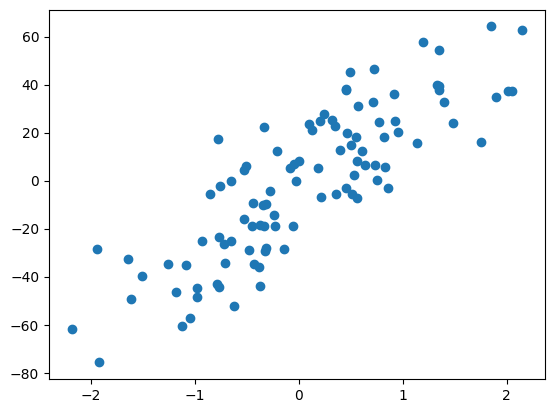

In [5]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, noise=20, random_state=13)
plt.scatter(X,y)

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
lr = LinearRegression()
lr.fit(X,y)
y_pred = lr.predict(X)
print(lr.coef_ , lr.intercept_)

[27.82809103] -2.29474455867698


In [8]:
from sklearn.linear_model import Ridge

In [10]:
rg = Ridge(alpha=10.0)
rg.fit(X,y)
print(rg.coef_ , rg.intercept_)

[24.9546267] -2.126913003523573


In [11]:
rg1 = Ridge(alpha=100.0)
rg1.fit(X,y)
print(rg1.coef_ , rg1.intercept_)

[12.93442104] -1.4248441496033308


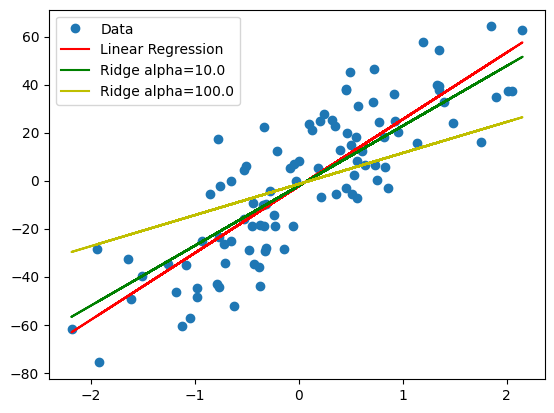

In [12]:
plt.plot(X,y, 'o')
plt.plot(X,y_pred, 'r-')
plt.plot(X,rg.predict(X), 'g-')
plt.plot(X,rg1.predict(X), 'y-')
plt.legend(['Data','Linear Regression','Ridge alpha=10.0', 'Ridge alpha=100.0'])
plt.show()

In [21]:
class MeraRidge:
    def __init__(self,alpha=0.1) -> None:
        self.alpha = alpha
        self.b = None
        self.m = None

    def fit(self , X_train , y_train):
        num = 0 
        den = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean()) * (X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())**2

        self.m = num / (den + self.alpha)
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m , self.b)

    def predict(self , X_test):
        pass

In [22]:
Mr = MeraRidge(alpha=10.0)

In [23]:
Mr.fit(X,y)

[24.9546267] [-2.126913]


## nD ridge from Scratch

In [27]:
class MeraRidge:
    def __init__(self,alpha=0.01) -> None:
        self.alpha = alpha
        self.b = None
        self.m = None

    def fit(self,X_train,y_train):
        X_train_new = np.insert(X_train , 0 , 1 , axis=1)
        I = np.identity(X_train.shape[1])
        result = np.linalg.inv(np.dot(X_train_new.T , X_train_new) + self.alpha * I).dot(X_train_new.T).dot(y_train)

        self.b = result[0]
        self.m = result[1:]
        print(self.b , self.m)

    def predict(self, X_test):
        y_pred = np.dot(X_test, self.m) + self.b
        print(y_pred)

In [28]:
reg = MeraRidge()
reg.fit(X,y)

-2.297135716314212 [27.82532321]


## With Gradient Descent

In [30]:
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
import numpy as np

In [32]:
X,y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=13)

In [51]:
reg = SGDRegressor(penalty='l2', alpha=0.001, max_iter=500 , eta0=0.1, learning_rate='constant')

In [52]:
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_ , reg.intercept_)

0.41052640759877723
[  11.30216841 -139.06648056  425.93890881  251.75206514   -9.3254354
  -58.03305696 -183.07389079  127.72327595  323.84350779  144.91149638] [155.70378672]


In [60]:
X_train.shape[1]

10

In [82]:
class RidgeRegressionGradient:
    def __init__(self,epochs,learning_rate,alpha):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coeff_ = None
        self.intercept_ = None

    def fit(self ,X_train , y_train):
        self.coeff_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        theta = np.insert(self.coeff_ , 0 , self.intercept_)

        X_train_new = np.insert(X_train , 0 , 1 , axis=1)

        for i in range(self.epochs):
            theta_der = np.dot(X_train_new.T,X_train_new).dot(theta) - np.dot(X_train_new.T , y_train) + self.alpha * theta
            theta = theta - theta_der * self.learning_rate

        self.coeff_= theta[1:]
        self.intercept_ = theta[0]
        print(self.coeff_ , self.intercept_)
        

In [87]:
class RidgeRegressionGradient:
    def __init__(self,epochs,learning_rate,alpha):
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)
        
        X_train = np.insert(X_train,0,1,axis=1)
        
        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der
        
        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]
        print(self.coef_ , self.intercept_)
    
    def predict(self,X_test):
        
        return np.dot(X_test,self.coef_) + self.intercept_

In [88]:
reg = RidgeRegressionGradient(alpha=0.001,epochs=500,learning_rate=0.005)
reg.fit(X_train , y_train)
y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))


[  -0.71874189 -194.95261746  526.06431734  305.64676991  -36.03327624
 -102.58033152 -209.90823525  127.79856819  395.21590212  155.40837888] 150.27034284974192
R2 score 0.3725295311377428
